## 1 Introduction


*Team members*
- Alexandre Dréan (2408681)
- Julien Segonne (2409827)

In [53]:
import pandas as pd
from scipy.io import mmread
import scipy.sparse as sp
import torch
import torch.nn as nn
from torch.optim import Adam
import scipy.sparse as sp
import numpy as np
from sentence_transformers import SentenceTransformer
import ast
import os
import matplotlib.pyplot as plt

In [3]:
ids = pd.read_csv('data/TP4-ids.csv', index_col=0)
articles = pd.concat([
    pd.read_csv('data/TP4-articles1.csv', index_col=0),
    pd.read_csv('data/TP4-articles2.csv', index_col=0)
], ignore_index=True)

adjacency = mmread('data/TP4-matrice-adjacence.dgt').tocsr() # Shape : (67294, 67294)

In [10]:
# Exemple trouver les articles cités par l'article n=1

n = 1
i = n - 1

cited_indices = adjacency[i].indices
cited_n = cited_indices + 1



cited_ids = ids[ids['n'].isin(cited_n)]['id'].values
cited_articles = articles[articles['id'].isin(cited_ids)][['id', 'title', 'year']]

cited_articles


,id,title,year
1,573695ff6e3b12023e513394,Exploring the Limits of Language Modeling.,2016
2,56d81592dabfae2eee6f4c65,A Hierarchical Pitman−Yor Process HMM for Unsu...,2011
3,53e9ad2db7602d97037103c6,Painless unsupervised learning with features,2010
4,53e9bd8cb7602d9704a36c0b,Unsupervised part-of-speech tagging with bilin...,2011
5,573696da6e3b12023e5d96a9,Labeled Grammar Induction with Minimal Supervi...,2015
6,5736960f6e3b12023e521c63,Recurrent Memory Network for Language Modeling,2016
7,5550401245ce0a409eb3205c,Dropout: a simple way to prevent neural networ...,2014
8,53e9982cb7602d970204e432,Phylogenetic Grammar Induction,2010
9,53e9a645b7602d9702f7362e,Noise-contrastive estimation: A new estimation...,2010
10,573695fd6e3b12023e51147e,Variational Dropout and the Local Reparameteri...,2015


## 2 PageRank algorithm

### 2.1 What is PageRank algorithm and why using it ?
TODO

### 2.2 PageRank code

In [17]:
# TODO

### 2.3 Performances

In [18]:
# TODO

### 2.4 Discussion

TODO

## 3 NGCF algorithm

### 3.1 What is NGCF algorithm and why using it ?

L'algorithme [Neural Graph Collaborative Filtering](./https://arxiv.org/pdf/1905.08108) à pour idée clé de partir du contenu d'un item et d'en faire un embedding, puis cet embedding est enrichi itérativement en parcourant le graphe de relation à partir de cet item. Les informations sémantique contenu dans les relations entre l'item et ces voisins viennent donc enrichir l'information encodé dans l'embedding associé à cet item. 

Cela est particulièrement pertinent dans le cadre de cette étude, en effet nous disposons d'informations pertinentes sur les articles en terme de contenu pur (titre, auteurs, abstract), mais le graphe de citation contient aussi des informations supplémentaires pertinentes, étudier les relations connus entre les articles pourrait par exemple permettre d'apprendre que certains auteurs se citent souvent entre sans pour autant être les auteurs avec les publications les plus proches, ce qui n'aurait pas été possible avec le contenu seul.

### 3.2 NGCF Code

In [4]:
# On commence par créer les embedding qui vont encoder le contenu des articles (titre, auteurs, année, abstract). On peut utiliser un modèle pré-entraîné de type Sentence-BERT pour cela. On utilise allenai-specter (https://arxiv.org/pdf/2004.07180) qui est entraîné spécifiquement sur des articles scientifiques. On concatène le titre et l'abstract pour créer un texte représentatif de chaque article, puis on encode ce texte pour obtenir une matrice d'embeddings initiale E0 de dimension (n_articles, 768).


def parse_authors(authors_str):
    '''Extrait les noms d'auteurs depuis la string de la colonne authors'''
    if pd.isna(authors_str) or authors_str == '':
        return ''
    try:
        authors_list = ast.literal_eval(authors_str)
        names = [a.get('name', '') for a in authors_list if isinstance(a, dict)]
        return ', '.join(names)
    except:
        return ''
    
def build_text(row):
    title    = '' if pd.isna(row.get('title'))    else str(row['title'])
    year     = '' if pd.isna(row.get('year'))     else str(int(row['year']))
    abstract = '' if pd.isna(row.get('abstract')) else str(row['abstract'])
    authors  = parse_authors(row.get('authors'))
    
    # Format SPECTER : "titre [SEP] contexte" et on met les auteurs et l'année dans la partie "contexte"
    context = f"{authors} {year} {abstract}".strip()
    return f"{title} [SEP] {context}"



def build_E0_aligned(articles, ids, model_name='allenai-specter'):
    '''
    Construit E0 dans le bon ordre : E0[i] correspond à l'article n=i+1
    '''

    model = SentenceTransformer(model_name)
    n_items = ids['n'].max()
    
    # Index articles par hex id pour lookup rapide
    articles_indexed = articles.set_index('id')
    
    texts = []
    missing = 0
    
    for _, row in ids.sort_values('n').iterrows():
        hex_id = row['id']
        
        if hex_id in articles_indexed.index:
            article = articles_indexed.loc[hex_id]
            text = build_text(article)
        else:
            text = ''
            missing += 1
        
        texts.append(text)
    
    print(f"proportion d'articles non présent dans les fichier articles.csv : {missing}/{n_items}")
    
    E0 = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    # Mettre à zéro les embeddings des articles sans texte
    empty_mask = [t == '' for t in texts]
    E0[empty_mask] = 0.0
    
    return E0  # shape (67294, embed_size)

In [5]:
if os.path.exists('E0_specter.npy'):
    E0 = np.load('E0_specter.npy')
    print(f"E0 chargé depuis le cache : {E0.shape}")
else:
    E0 = build_E0_aligned(articles, ids)
    np.save('E0_specter.npy', E0)
    print(f"E0 calculé et sauvegardé : {E0.shape}")

np.save('E0_specter.npy', E0)

E0 chargé depuis le cache : (67294, 768)


In [45]:
class NGCF_ItemItem(nn.Module):
    def __init__(self, E0, adjacency, n_layers=3, embed_size=256):
        super().__init__()
        n_items = E0.shape[0]
        input_dim  = E0.shape[1] # 768 pour SPECTER -> trop lourd pour ma VRAM je réduis à 256


        self.register_buffer('E0_frozen', torch.tensor(E0, dtype=torch.float32)) # on ne l'optimise pas directement, mais on peut y accéder pour faire de la régularisation L2


        self.proj = nn.Linear(input_dim, embed_size, bias=False)
        
        # Embedding initial (depuis CLIP/SBERT)
        self.E0 = nn.Parameter(torch.tensor(E0, dtype=torch.float32))
        
        # Matrices W pour chaque couche
        self.W1 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False) 
                                  for _ in range(n_layers)])
        self.W2 = nn.ModuleList([nn.Linear(embed_size, embed_size, bias=False) 
                                  for _ in range(n_layers)])
        
        # Si on normalise pas entre les couches les valeurs explosent et ça diverge donc on ajoute une normalisation après chaque couche
        self.norms = nn.ModuleList([nn.LayerNorm(embed_size) for _ in range(n_layers)])

        
        self.L = self.normalize(adjacency)  # (L = D^-1/2 · A · D^-1/2)
        self.n_layers = n_layers

    def normalize(self, A):
        degrees = np.array(A.sum(axis=1)).flatten()
        D_inv_sqrt = sp.diags(1.0 / np.sqrt(degrees + 1e-8))
        L = D_inv_sqrt @ A @ D_inv_sqrt

        # on garde la matrice creuse pour les perfs
        L_coo = L.tocoo()
        indices = torch.tensor([L_coo.row, L_coo.col], dtype=torch.long)
        values = torch.tensor(L_coo.data, dtype=torch.float32)
        return torch.sparse_coo_tensor(indices, values, L.shape).coalesce()

    def forward(self):


        # on utilise l'autocast pour réduire la précision à float16 et économiser de la VRAM, car les matrices sont grandes et les calculs lourds. Cela peut accélérer l'entraînement sur GPU tout en gardant une précision suffisante pour ce type de tâche.
        # # sparse.mm ne supporte pas float16 sur CUDA donc on fait la propagation en float32 et on cast après
        E = self.proj(self.E0_frozen.float())
        # print(f"  après proj — NaN: {torch.isnan(E).sum()}, min/max: {E.min():.4f}/{E.max():.4f}")
        all_embeddings = [E]
        for l in range(self.n_layers):
            LE = torch.sparse.mm(self.L, E.float())
            LE = nn.functional.normalize(LE, p=2, dim=1)
            with torch.autocast(device_type='cuda', dtype=torch.float16): 
                # on propage les embeddings à travers le graphe
                # (L+I)E.W1  +  L(E°E).W2
                term1 = self.W1[l](LE + E)           # (L+I)E.W1
                # print(f"  couche {l} term1 — NaN: {torch.isnan(term1).sum()}")
                term2 = self.W2[l](LE * E)            # L(E°E).W2
                # print(f"  couche {l} term2 — NaN: {torch.isnan(term2).sum()}")
                E = nn.functional.leaky_relu(term1 + term2)
                E = self.norms[l](E)
                # print(f"  couche {l} après leakyrelu — NaN: {torch.isnan(E).sum()}, min/max: {E.min():.4f}/{E.max():.4f}")
            all_embeddings.append(E)
            
        # Concatenation de toutes les couches
        E_concat = torch.cat(all_embeddings, dim=1)
        return E_concat

    def bpr_loss(self, E_concat, i, j, k):
        # i cite j (positif), i ne cite pas k (négatif)
        e_i = E_concat[i]
        e_j = E_concat[j]
        e_k = E_concat[k]
        
        pos_score = (e_i * e_j).sum(dim=1)
        neg_score = (e_i * e_k).sum(dim=1)
        
        loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-8).mean()
        return loss
    

def get_training_pairs(adjacency):
    '''
    Extrait toutes les paires (i, j) positives depuis la matrice d'adjacence
    '''
    adjacency_coo = adjacency.tocoo()
    rows = adjacency_coo.row  # articles citants
    cols = adjacency_coo.col  # articles cités
    return rows, cols


def train(model, adjacency, n_epochs=50, batch_size=1024, lr=1e-4, lambda_reg=1e-5, checkpoint_path='checkpoint.pt'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.L = model.L.to(device)

    torch.cuda.empty_cache()
    scaler = torch.amp.GradScaler() # pour gérer l'autocast et éviter les problèmes de sous-flux de gradients en float16    
    optimizer = Adam(model.parameters(), lr=lr)
    

    start_epoch = 0
    loss_history = []
    if os.path.exists(checkpoint_path):
        print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scaler.load_state_dict(checkpoint['scaler_state'])
        start_epoch = checkpoint['epoch'] + 1
        loss_history = checkpoint['loss_history']
        print(f"Reprise à l'epoch {start_epoch + 1}/{n_epochs}")



    # Extraire toutes les paires positives
    rows, cols = get_training_pairs(adjacency)
    n_pairs = len(rows)
    n_items = adjacency.shape[0]
    
    print(f"Nb paires positives : {n_pairs}")
    print(f"Training sur : {device}")

    for epoch in range(start_epoch, n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")
        model.train()

        # on shuffle les paires à chaque époque
        perm = np.random.permutation(n_pairs)
        rows_shuffled = rows[perm]
        cols_shuffled = cols[perm]
        
        total_loss = 0
        n_batches = 0
        for start in range(0, n_pairs, batch_size):
            print(f"\rBatch {start//batch_size + 1}/{(n_pairs + batch_size - 1) // batch_size}",end="", flush=True)
            i_batch = rows_shuffled[start:start + batch_size]
            j_batch = cols_shuffled[start:start + batch_size]
            k_batch = np.random.randint(0, n_items, size=len(i_batch)) # quasiment sur que k_batch ne contient pas de paires positives (i, k) car la matrice est très creuse, mais même si c'était le cas ça ne changerait rien à l'entrainement par loi des grands nombres.
            
            i_t = torch.tensor(i_batch, dtype=torch.long).to(device)
            j_t = torch.tensor(j_batch, dtype=torch.long).to(device)
            k_t = torch.tensor(k_batch, dtype=torch.long).to(device)
            
            optimizer.zero_grad()
            E_concat = model()

            # print(f"E_concat NaN: {torch.isnan(E_concat).sum()}, Inf: {torch.isinf(E_concat).sum()}")
            # print(f"E_concat min/max: {E_concat.min():.4f} / {E_concat.max():.4f}")

            
            # BPR loss avec régularisation L2
            loss = model.bpr_loss(E_concat, i_t, j_t, k_t) 
            # on régularise plutôt les poids de la projection linéaire que les embeddings initiaux, pour éviter de contraindre trop fortement les embeddings pré-entraînés qui contiennent déjà beaucoup d'information utile
            reg = lambda_reg * model.proj.weight.norm(2).pow(2)
            loss += reg

            # backward et update
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            del E_concat
            torch.cuda.empty_cache()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}")
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scaler_state': scaler.state_dict(),
            'loss': avg_loss,
            'loss_history': loss_history
        }, checkpoint_path)
        print(f"Checkpoint sauvegardé (epoch {epoch+1})")

    
    return model, loss_history

In [46]:
model = NGCF_ItemItem(E0, adjacency=adjacency, n_layers=3, embed_size=128)

In [47]:
model = train(model, adjacency, n_epochs=30, batch_size=2048, lr=1e-4)

Nb paires positives : 621195
Training sur : cuda
Epoch 1/30
Batch 304/304Epoch 1/30 — Loss: 0.1779
Checkpoint sauvegardé (epoch 1)
Epoch 2/30
Batch 304/304Epoch 2/30 — Loss: 0.0877
Checkpoint sauvegardé (epoch 2)
Epoch 3/30
Batch 304/304Epoch 3/30 — Loss: 0.0758
Checkpoint sauvegardé (epoch 3)
Epoch 4/30
Batch 304/304Epoch 4/30 — Loss: 0.0681
Checkpoint sauvegardé (epoch 4)
Epoch 5/30
Batch 196/304

KeyboardInterrupt: 

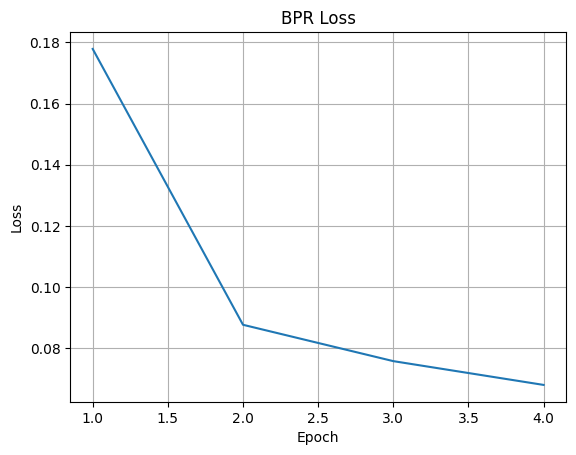

In [54]:
checkpoint = torch.load('checkpoint.pt')
loss_history = checkpoint['loss_history']
plt.plot(range(1, len(loss_history)+1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('BPR Loss')
plt.grid(True)
plt.show()


In [ ]:
def generate_recommendations(model, test_ids, ids, adjacency, device='cuda', top_k=20):
    '''
    test_ids : DataFrame de test
    ids      : DataFrame de correspondance n <-> id
    '''
    model.eval()
    model = model.to(device)
    model.L = model.L.to(device)
    
    idx_to_hexid = ids.set_index('n')['id'].to_dict()
    
    with torch.no_grad():
        E_concat = model()  # (n_items, embed_size * (n_layers+1))
    
    results = []
    
    for _, row in test_ids.iterrows():
        hex_id = row['id']
        idx = row['idx']
        i = idx - 1 
        
        scores = (E_concat @ E_concat[i])  # (n_items,)
        

        # on retire les articles déjà cités par i de la liste de recommandations et l'article lui-même
        known_cited = adjacency.getrow(i).indices
        scores[known_cited] = -float('inf')
        scores[i] = -float('inf')
        
        # Top 20
        top20_indices = scores.argsort(descending=True)[:top_k].cpu().numpy()
        
        top20_hexids = [idx_to_hexid[idx + 1] for idx in top20_indices]  # +1 car ids est 1-based
        
        results.append({
            'id': hex_id,
            'recommandations': ' '.join(top20_hexids)
        })
    
    return pd.DataFrame(results)

In [ ]:
checkpoint_path = 'checkpoint.pt'

if os.path.exists(checkpoint_path):
    print(f"Checkpoint trouvé, reprise depuis {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cuda')
    model.load_state_dict(checkpoint['model_state'])


test_ids = pd.read_csv('data/TP4-ids-test.csv', index_col=0)
recommendations = generate_recommendations(model, test_ids, ids, adjacency)
recommendations.to_csv('soumissionNGCF.csv', index=False)
print(recommendations.head())




Checkpoint trouvé, reprise depuis checkpoint.pt
torch.Size([67294, 512])
                         id                                    recommandations
0  56d87c8bdabfae2eee45fce6  53e9bcd9b7602d97049602cb 56d90157dabfae2eeed96...
1  53e9b7d9b7602d9704389448  53e99e6ab7602d970272ee1b 53e9b857b7602d970441c...
2  53e99e04b7602d97026ca90e  53e9a4c0b7602d9702de31c9 53e9b6bfb7602d9704246...
3  53e9b32bb7602d9703dfdacf  53e99eaeb7602d97027765e8 53e9a97ab7602d97032d1...
4  53e9b9adb7602d970459ef8c  557dbd5fd19faf961d163753 53e9be57b7602d9704b1a...


## 4 Third algorithm

## 5 Fourth algorithm